In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import zipfile, os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Step 1: Download and extract dataset
url = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
path_to_zip = tf.keras.utils.get_file('cats_and_dogs_filtered.zip', origin=url)

extract_path = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')
with zipfile.ZipFile(path_to_zip, 'r') as zip_ref:
    zip_ref.extractall(os.path.dirname(path_to_zip))

train_dir = os.path.join(extract_path, 'train')
validation_dir = os.path.join(extract_path, 'validation')

68606236/68606236 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Step 2: Data generators
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [4]:
# Step 3: Build the model with MobileNetV2
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Step 4: Train the model
history = model.fit(
    train_generator,
    epochs=3,
    validation_data=validation_generator
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7565 - loss: 0.4859 - val_accuracy: 0.9390 - val_loss: 0.1604
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9205 - loss: 0.1973 - val_accuracy: 0.9620 - val_loss: 0.1193
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9368 - loss: 0.1577 - val_accuracy: 0.9580 - val_loss: 0.1078


In [6]:
# Step 5: Save the model
model.save('cat_dog_model.keras')

In [9]:
def plot_predictions(model, generator, class_names, num_images=5):
    plt.figure(figsize=(15, 5))
    batch = next(generator)  # Corrected line
    images, labels = batch

    predictions = model.predict(images)

    for i in range(num_images):
        ax = plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])
        pred_label = class_names[int(predictions[i] > 0.5)]
        true_label = class_names[int(labels[i])]
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


<ipython-input-9-fd503a614d7b>:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_label = class_names[int(predictions[i] > 0.5)]


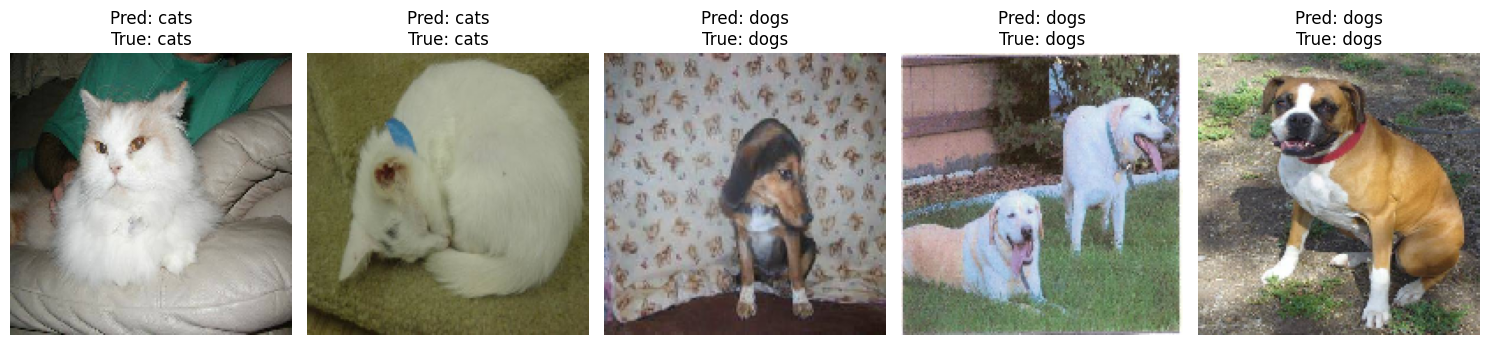

In [10]:
# Get class names
class_names = list(train_generator.class_indices.keys())

# Display test samples with predictions
plot_predictions(model, validation_generator, class_names, num_images=5)


## Trained Keras model to TensorFlow Lite (TFLite) format to reduce deployment complexity

In [11]:
# This step is for to reduse the model complexity in deployment
# Load the Keras model
model = tf.keras.models.load_model("cat_dog_model.keras")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model
with open("cat_dog_model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp_p1dxg86'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140276665595664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140276665596624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140276665597008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140276665596816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140276665594896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140276665596240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140276536509456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140276536508496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140276665595088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140276536509840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1402765365109